# **Initialization**

In [1]:
import os
import warnings
warnings.simplefilter("ignore")
from pathlib import Path
import pandas as pd
import arviz as az
import arviz_stats as azs
import bambi as bmb
import matplotlib.pyplot as plt
import helper
import pickle
import arviz_plots as azp
plt.style.use('default')
plt.rcParams['font.family']='Times New Roman'
_p=Path(os.getcwd())
p=_p.parent

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
# Importing Nightingale 2002 & 2007 data
df=pd.read_csv(p/'processed-data/master.csv')
df=pd.DataFrame(df.loc[:,['r3','sex','loading']],columns=['r3','sex','loading'])

# Importing Winkelstein2000 data
df_wnkf=pd.read_csv(p.parent/'data/Winkelstein2000/clean-data/a09-flexion-moment.csv')
df_wnke=pd.read_csv(p.parent/'data/Winkelstein2000/clean-data/a08-extension-moment.csv')
wnke_m=df_wnke.A2.mean()
wnke_sd=df_wnke.A2.std()
wnkf_m=df_wnkf.A2.mean()
wnkf_sd=df_wnkf.A2.std()

# <center> **Hierarchical Model - For 3 Nm - Nightingale 2002 & 2007** </center>

## Defining Priors and Model Fitting

$$
            \begin{array}{rcl}
            \text{sigma} &\sim & \operatorname{HalfStudentT}(4,~3.37)\\\text{loading} &\sim & \operatorname{Normal}(\text{[5.25,~5.78]},~\text{[2.31,~2.94]})\\\text{loading|sex-sigma} &\sim & \operatorname{HalfNormal}(\text{[2.31,~2.94]})\\\text{loading|sex-offset} &\sim & \operatorname{Normal}(0,~1)\\\text{loading|sex} &\sim & \operatorname{Deterministic}(f(\text{loading|sex-offset},~\text{loading|sex-sigma}))\\\text{mu} &\sim & \operatorname{Deterministic}(f(\text{loading},~\text{loading|sex-offset},~\text{loading|sex-sigma}))\\\text{r3} &\sim & \operatorname{Normal}(\text{mu},~\text{sigma})
            \end{array}
            $$

In [3]:
# Defining priors
my_priors={
    'loading': bmb.Prior('Normal', mu=[wnke_m, wnkf_m], sigma=[wnke_sd*1.5, wnkf_sd*1.5]),
    'loading|sex': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=[wnke_sd*1.5, wnkf_sd*1.5]))
}

# Defining model
mod=bmb.Model('r3~0+loading+(0+loading|sex)',df,priors=my_priors)

# Model fitting
inf=mod.fit(draws=1500,target_accept=0.95,random_seed=12345,idata_kwargs={"log_likelihood": True,"log_prior": True})

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, loading, loading|sex_sigma, loading|sex_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_500 draw iterations (4_000 + 6_000 draws total) took 517 seconds.


## Graph

<center>

| *In Graph*      | *In Manuscript*      | *Type* | *Definition*     |
| :-----------: | :-----------: | :---------------------------------: |:---------------------------------:|
| *r3* | $ R $ | Likelihood | Segmental rotation angle at 3 Nm |
| *loading* | $ L_{i} $ | Common effects | Coefficient for loading mode |
| *loading\|sex* | $ l_{ij} $ | Group-specific effects | Coefficient for loading mode specific to the sex |
| *loading\|sex_sigma* | $ \sigma_{l_{i}} $ | Hyperprior | Error term for the group-specific effect  |
| *sigma* | $ E $ | Overall error | Residual random error |

</center>

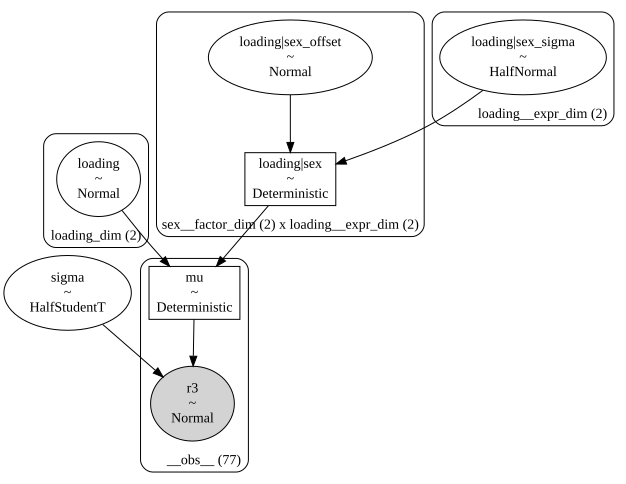

In [4]:
mod.graph()

## Plotting Priors (Fig. A2)

Sampling: [loading, loading|sex_sigma, sigma]


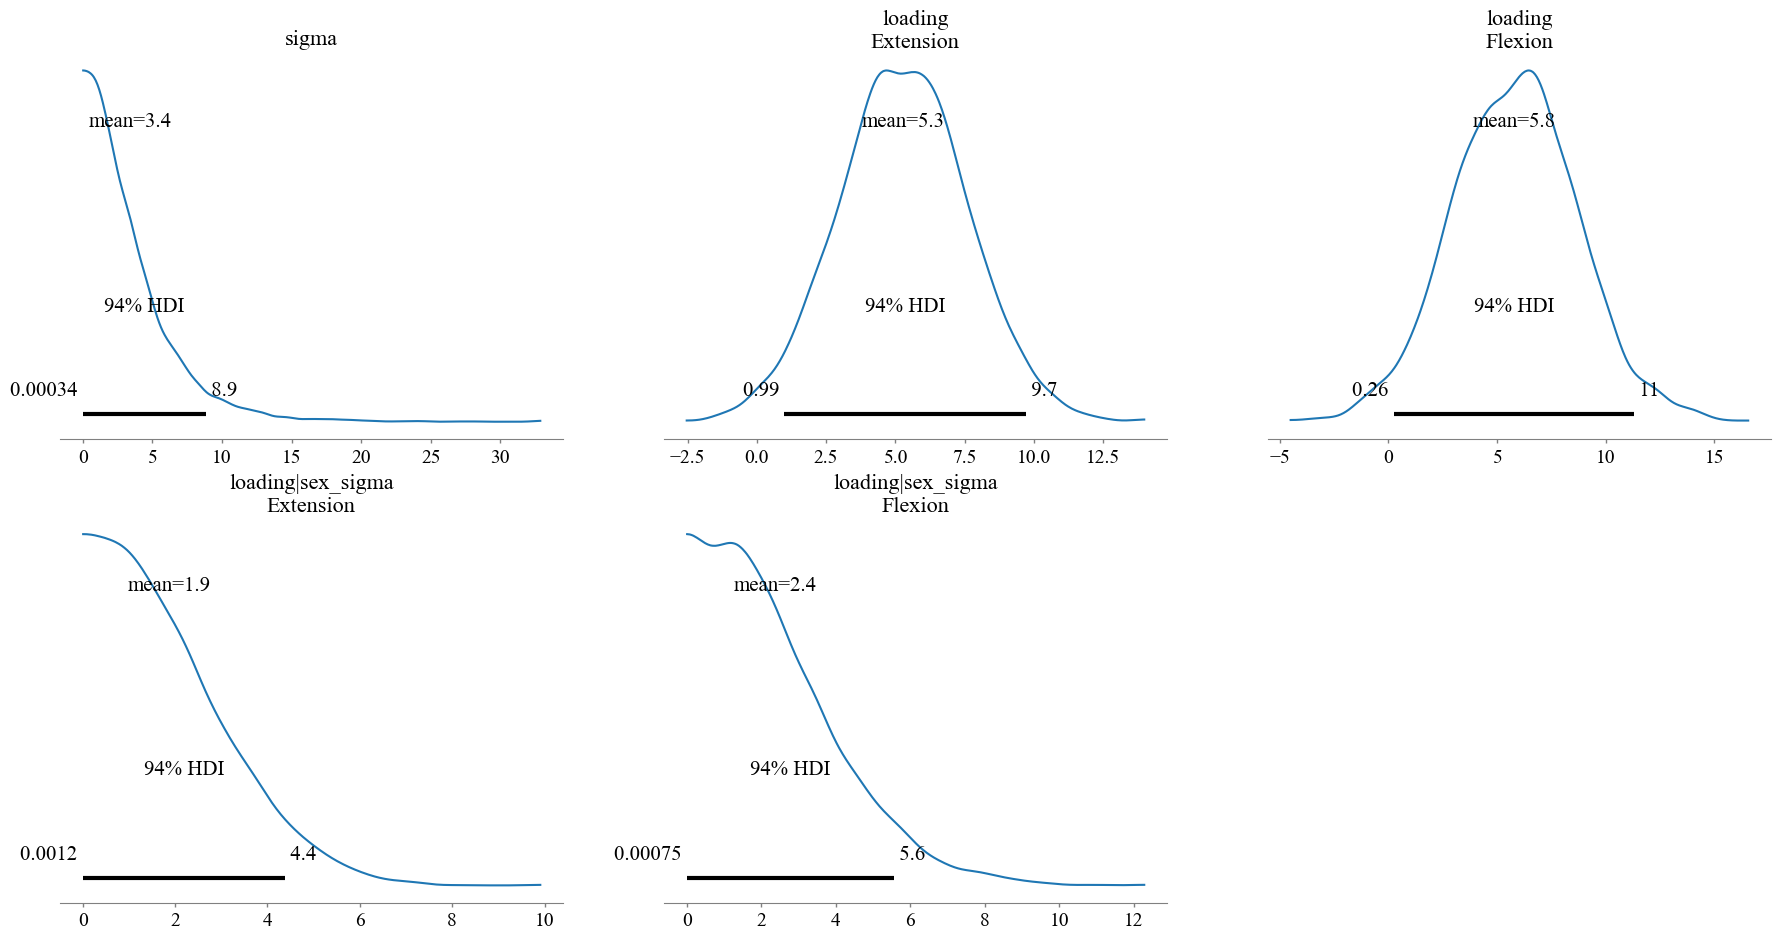

In [5]:
mod.plot_priors();

## Posterior Predictive Distribution (Fig. A3)

Text(0.5, 0, 'Rotation at 3 Nm')

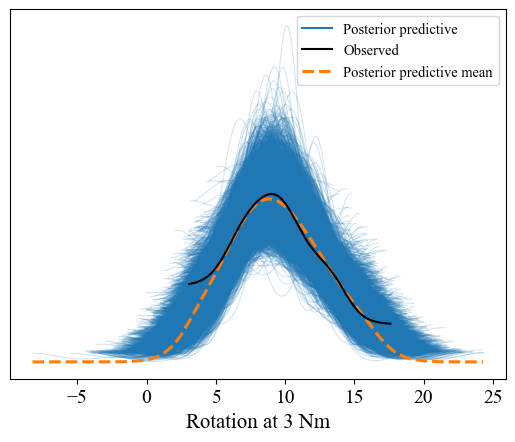

In [6]:
mod.predict(inf,kind='response')
az.plot_ppc(inf)
plt.xlabel('Rotation at 3 Nm')

## Prior Predicitve Distribution

Sampling: [loading, loading|sex_offset, loading|sex_sigma, r3, sigma]


<Axes: xlabel='r3'>

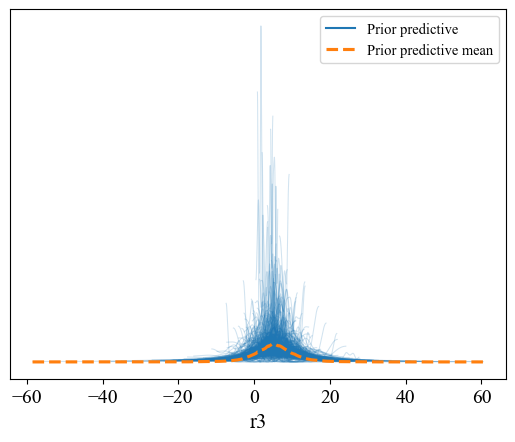

In [7]:
inf_prior=mod.prior_predictive()
az.plot_ppc(inf_prior,group="prior")

## Traces (Fig. A4)

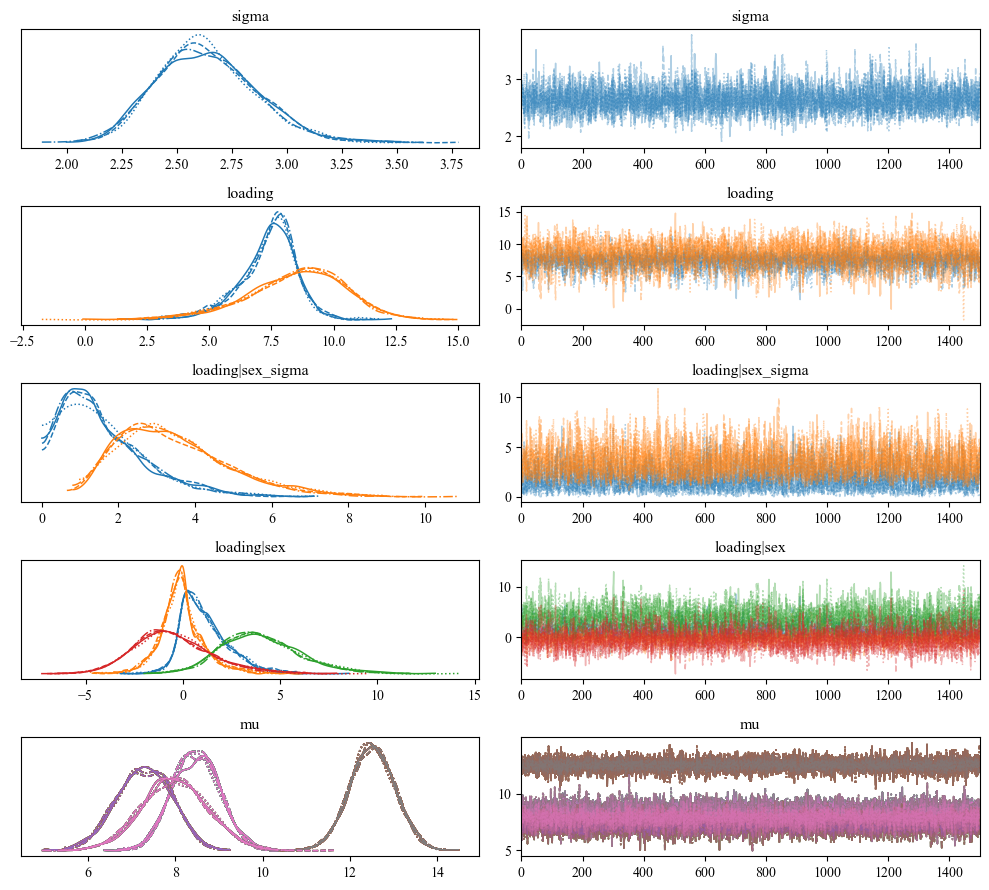

In [8]:
az.plot_trace(inf,figsize=[10,9])  #,legend=True,var_names=['~mu']
plt.tight_layout()

## Forest Plot (Fig. 1)

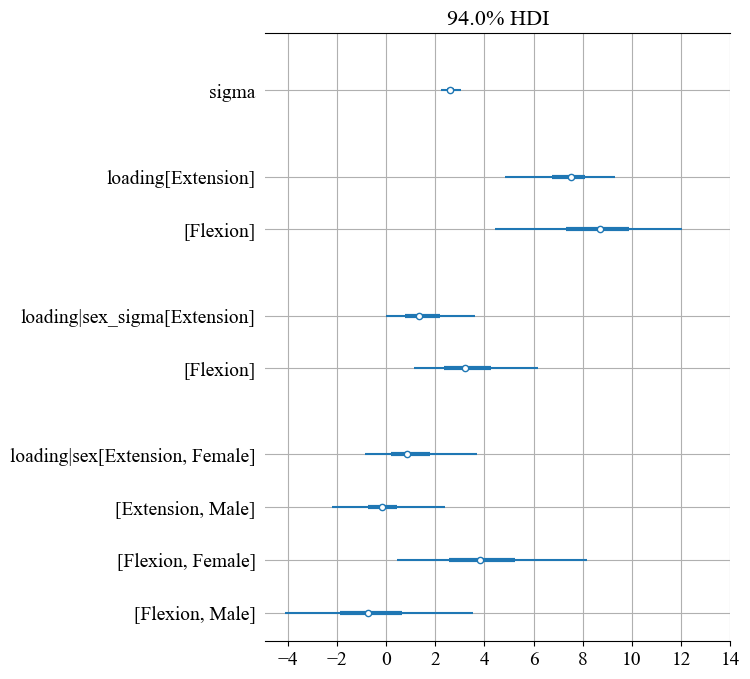

In [9]:
az.plot_forest(inf,var_names=['~mu'],combined=True)
plt.grid(True)
plt.xticks([i for i in range(-4,15,2)]);

## Summary (Table AIII)

In [10]:
az.summary(inf,var_names=['~mu'],hdi_prob=0.94).round(2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.64,0.23,2.23,3.06,0.00,0.00,4645.0,3705.0,1.0
loading[Extension],7.35,1.19,4.83,9.31,0.03,0.02,2151.0,1817.0,1.0
loading[Flexion],8.52,2.00,4.43,12.03,0.04,0.03,2381.0,2917.0,1.0
loading|sex_sigma[Extension],1.59,1.12,0.00,3.63,0.02,0.02,1925.0,1958.0,1.0
loading|sex_sigma[Flexion],3.45,1.45,1.13,6.19,0.03,0.02,2694.0,3061.0,1.0
"loading|sex[Extension, Female]",1.12,1.26,-0.84,3.72,0.03,0.02,1994.0,2205.0,1.0
"loading|sex[Extension, Male]",-0.07,1.16,-2.20,2.42,0.02,0.02,2423.0,2270.0,1.0
"loading|sex[Flexion, Female]",4.00,2.06,0.43,8.18,0.04,0.03,2377.0,2975.0,1.0
"loading|sex[Flexion, Male]",-0.53,2.01,-4.10,3.52,0.04,0.03,2551.0,2991.0,1.0


## Contrast Plots - Prior

### Prior Contrast of Sex Differences corresponding to Loading Mode

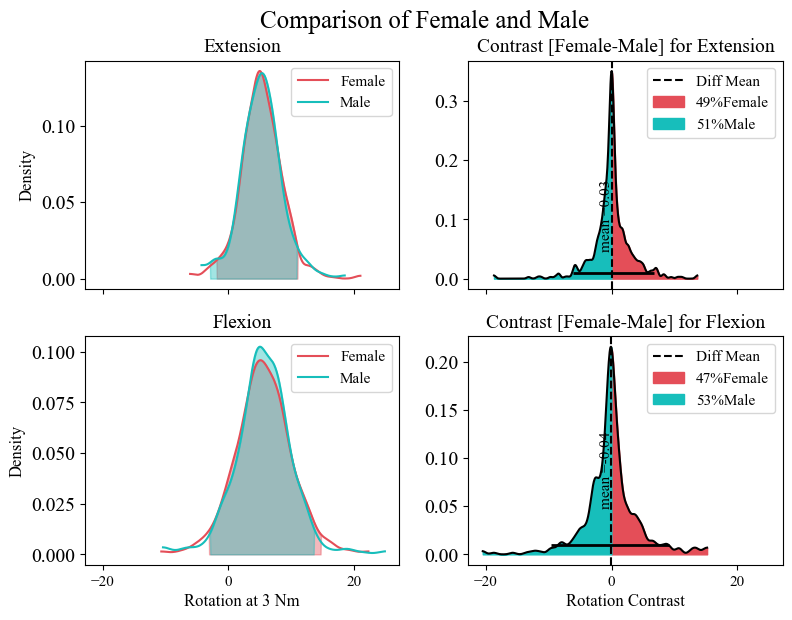

In [11]:
helper.plot_contrast(inf_prior,'sex differences','Prior')

### Prior Contrast of Loading Differences (F-E) corresponding to Sex

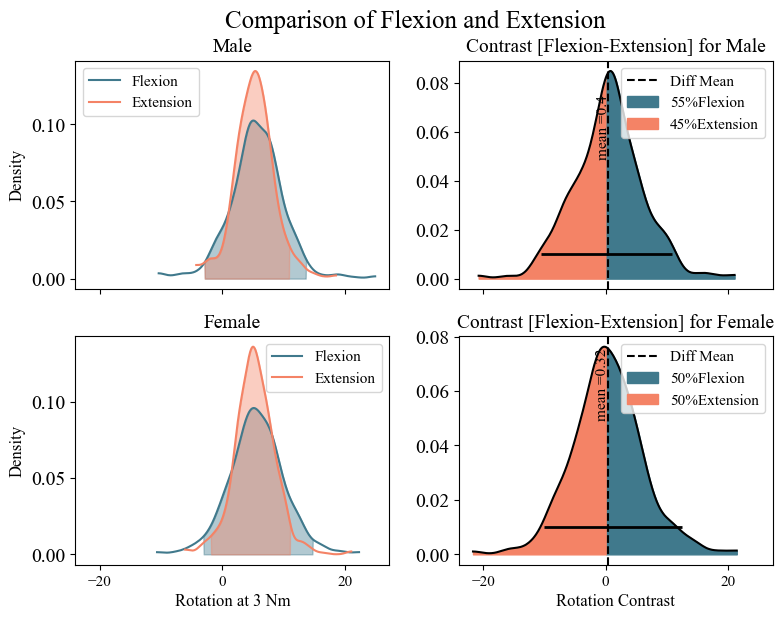

In [12]:
helper.plot_contrast(inf_prior,'loading differences','Prior')

## Contrast Plots - Posterior Predictive

### Posterior Predictive Contrast of Sex Differences corresponding to Loading Mode (Fig. 3)

In Extension, Female is more flexible than Male by 1.19°

In Flexion, Female is more flexible than Male by 4.53°

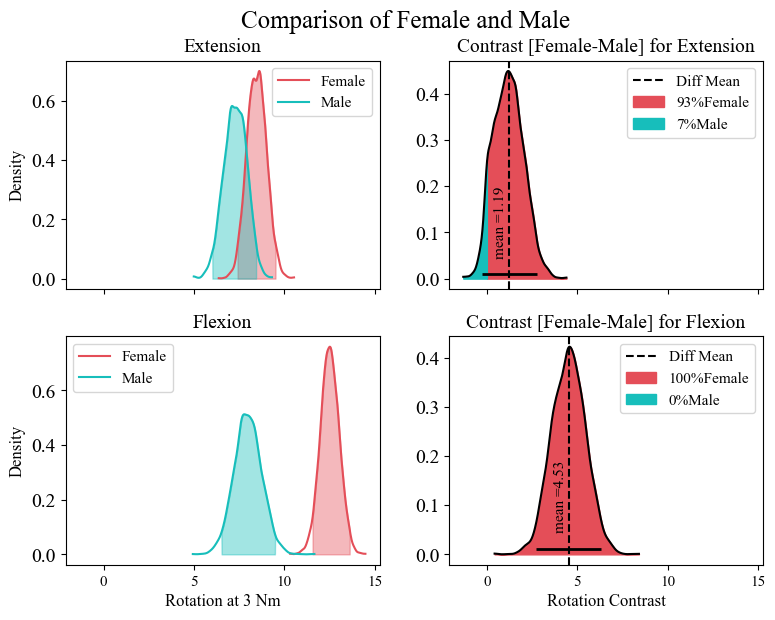

In [13]:
helper.plot_contrast(inf,'sex differences','Posterior')

### Posterior Contrast of Loading Differences (F-E) corresponding to Sex (Fig. 2)

In Male, Flexion is more than Extension by 0.71°

In Female, Flexion is more than Extension by 4.04°

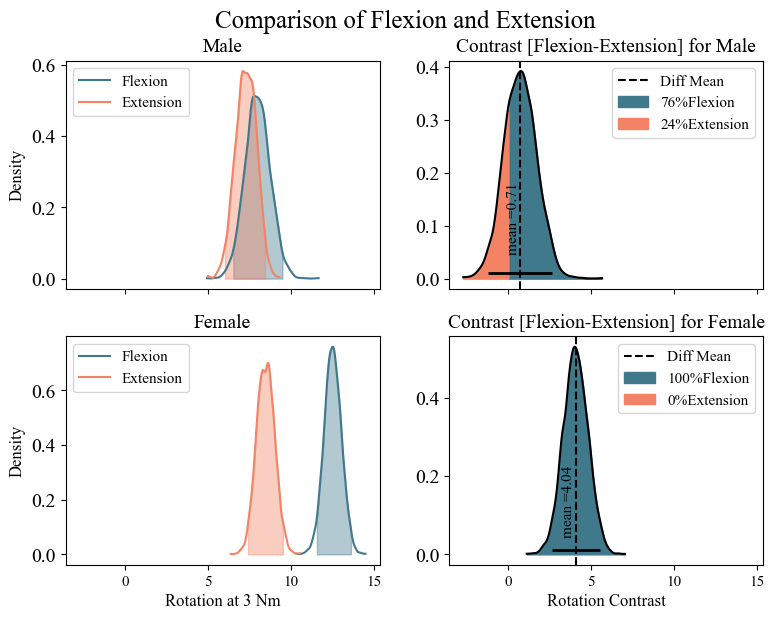

In [14]:
helper.plot_contrast(inf,'loading differences','Posterior')

## Prior Check

In [15]:
azs.psense_summary(inf,var_names=['~mu'])

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/Exploratory-Analysis-of-Bayesian-Models/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
sigma,0.018,0.156,✓
loading[Extension],0.061,0.015,potential strong prior / weak likelihood
loading[Flexion],0.085,0.010,potential strong prior / weak likelihood
loading|sex_sigma[Extension],0.102,0.037,potential strong prior / weak likelihood
loading|sex_sigma[Flexion],0.083,0.016,potential strong prior / weak likelihood
"loading|sex[Extension, Female]",0.060,0.034,potential strong prior / weak likelihood
"loading|sex[Extension, Male]",0.061,0.017,potential strong prior / weak likelihood
"loading|sex[Flexion, Female]",0.090,0.021,potential strong prior / weak likelihood
"loading|sex[Flexion, Male]",0.082,0.010,potential strong prior / weak likelihood


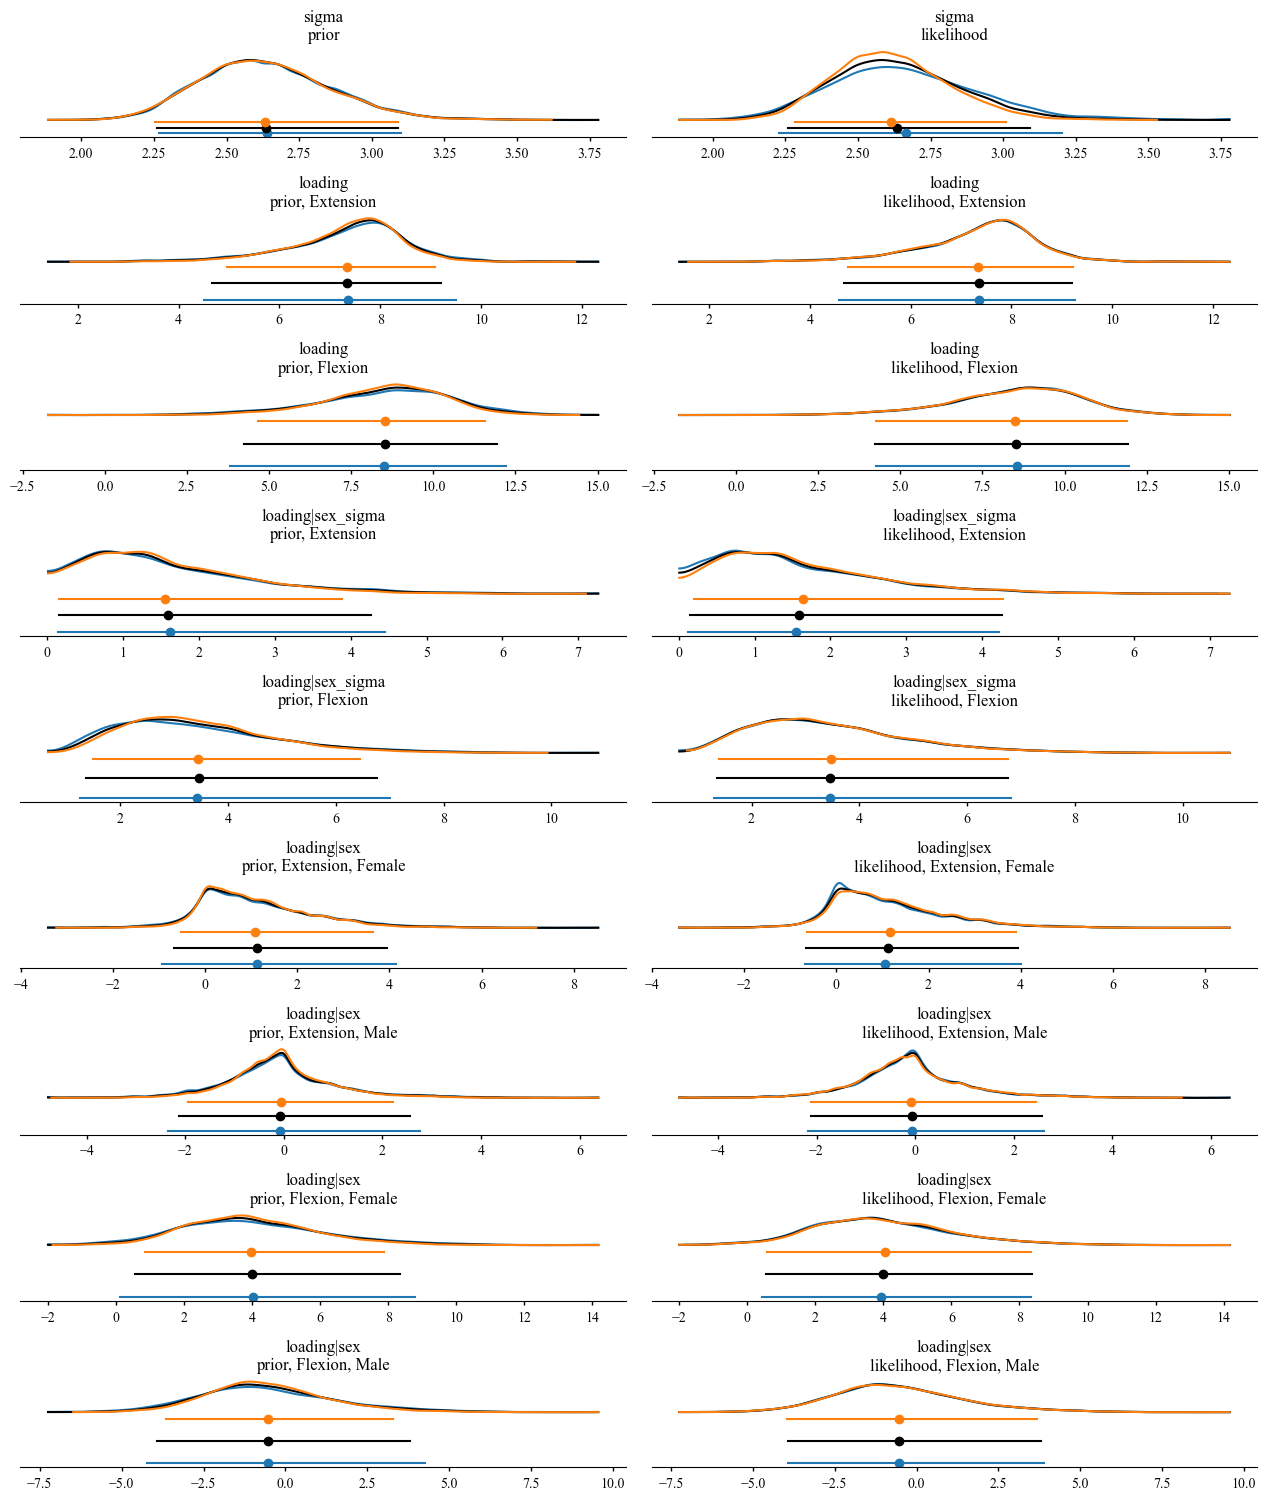

In [16]:
plt.style.use('default')
plt.rcParams['font.family']='Times New Roman'
azp.plot_psense_dist(inf,var_names=['~mu'],kind="kde")
plt.tight_layout()

## LOO Diagnostics

In [17]:
az.loo(inf)

Computed from 6000 posterior samples and 77 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -186.10     6.81
p_loo        4.83        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.5]   (good)       77  100.0%
 (0.5, 0.7]   (ok)          0    0.0%
   (0.7, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

## Saving the inference data

In [18]:
'''with open(p/'processed-data/multilevel-model-inference.pkl','wb') as buff:
    pickle.dump(inf,buff)'''

"with open(p/'processed-data/multilevel-model-inference.pkl','wb') as buff:\n    pickle.dump(inf,buff)"

To load the data from the pickle file, remove the comment markers from the code below and run the cell.


In [19]:
'''my_priors={
    'loading': bmb.Prior('Normal', mu=[wnke_m, wnkf_m], sigma=[wnke_sd*1.5, wnkf_sd*1.5]),
    'loading|sex': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=[wnke_sd*1.5, wnkf_sd*1.5]))
}
mod=bmb.Model('r3~0+loading+(0+loading|sex)',df,priors=my_priors)
mod.build()
with open(p/'processed-data/multilevel-model-inference.pkl','rb') as buff:
    inf=pickle.load(buff)
inf_prior=mod.prior_predictive(draws=500)'''

"my_priors={\n    'loading': bmb.Prior('Normal', mu=[wnke_m, wnkf_m], sigma=[wnke_sd*1.5, wnkf_sd*1.5]),\n    'loading|sex': bmb.Prior('Normal', mu=0, sigma=bmb.Prior('HalfNormal', sigma=[wnke_sd*1.5, wnkf_sd*1.5]))\n}\nmod=bmb.Model('r3~0+loading+(0+loading|sex)',df,priors=my_priors)\nmod.build()\nwith open(p/'processed-data/multilevel-model-inference.pkl','rb') as buff:\n    inf=pickle.load(buff)\ninf_prior=mod.prior_predictive(draws=500)"

In [20]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pytensor,xarray

Last updated: Fri Apr 04 2025

Python implementation: CPython
Python version       : 3.11.9
IPython version      : 8.25.0

pytensor: 2.23.0
xarray  : 2025.1.2

pandas     : 2.2.2
matplotlib : 3.8.4
pathlib    : 1.0.1
arviz      : 0.17.1
bambi      : 0.14.0
arviz_plots: 0.4.0
arviz_stats: 0.5.0.dev0

Watermark: 2.5.0

